# Spark SQL

---

In [39]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()
user_profiles = spark.read.csv("file:///C:/docs/user_profiles.csv", header=True, inferSchema=True)
user_profiles.show(5)

+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|user_id|         name|               email|gender|date_of_birth|country|signup_date|is_active|followers_count|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------------+
|    101|     John Doe|john.doe@example.com|  Male|   1990-05-15|    USA| 2020-01-10|     true|           1500|
|      2|   Jane Smith|jane.smith@exampl...|Female|   1985-08-20| Canada| 2019-03-15|     true|           2300|
|      3| Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|     UK| 2021-07-01|    false|            800|
|      4|  Emily Davis|emily.davis@examp...|Female|   1995-02-25|  India| 2020-05-20|     true|           1200|
|      5|Michael Brown|michael.brown@exa...|  Male|   1988-09-12|    USA| 2018-11-30|     true|           4500|
+-------+-------------+--------------------+------+-------------+-------+-----------+---------+---------

In [ ]:
user_profiles.createOrReplaceTempView("user_profiles_view")

In [ ]:
user_profiles.createTempView("user_profiles_view")

## Temporary View (`TEMP VIEW`)

### What Are Temporary Views in PySpark SQL?

In PySpark, a temporary view is a named view of a DataFrame that exists only for the duration of our Spark session. 

It allows us to run SQL queries on our DataFrame using Spark SQL syntax — like working with tables in a traditional SQL database, but without needing to load the data into an actual database

A Temporary View is a logical table that exists **only within the current Spark session**.

### Key Characteristics:

- 🌐 **Session-scoped** (visible only in the current SparkSession)
- 🧹 **Deleted automatically** when the session stops
- 📌 Stored in the **session catalog**
- 🔄 Can be replaced using `CREATE OR REPLACE`

Now that we’ve created a temporary view called customer_feedback, we can treat it just like a SQL table and run SQL queries using the spark.sql() method.

### Applying SQL Queries

In [10]:
spark.sql("select * from user_profiles_view").show()

+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|user_id|           name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|
+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|    101|       John Doe|john.doe@example.com|  Male|   1990-05-15|      USA| 2020-01-10|     true|           1500|
|      2|     Jane Smith|jane.smith@exampl...|Female|   1985-08-20|   Canada| 2019-03-15|     true|           2300|
|      3|   Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|       UK| 2021-07-01|    false|            800|
|      4|    Emily Davis|emily.davis@examp...|Female|   1995-02-25|    India| 2020-05-20|     true|           1200|
|      5|  Michael Brown|michael.brown@exa...|  Male|   1988-09-12|      USA| 2018-11-30|     true|           4500|
|      6|   Sarah Wilson|sarah.wilson@exam...|Female|   1993-06-18|Austr

In [43]:
spark.sql("select user_id, gender from user_profiles_view where gender == 'Male'").show(10)

+-------+------+
|user_id|gender|
+-------+------+
|    101|  Male|
|      3|  Male|
|      5|  Male|
|      7|  Male|
|      9|  Male|
|     11|  Male|
|     13|  Male|
|     15|  Male|
|     17|  Male|
|     19|  Male|
+-------+------+
only showing top 10 rows



In [ ]:
spark.sql("SELECT COUNT(DISTINCT country) AS Different_locations FROM user_profiles_view").show()

+-------------------+
|Different_locations|
+-------------------+
|                  7|
+-------------------+



# Global Temporary View in Spark SQL

## What is a Global Temporary View?
A **Global Temporary View** is a logical table that is **shared across all Spark sessions** within the same Spark application.

Unlike a normal temporary view (which is session-scoped), a global temporary view is **application-scoped**, meaning:
- It remains available across multiple sessions, notebooks, and threads.
- It only disappears when the **Spark application stops**.

## Key Characteristics
- 🌐 **Shared across all SparkSessions** in the same application.
- 🗂 Stored inside a special Spark-managed database called **`global_temp`**.
- 🕒 Lifetime: valid until the **Spark application ends**.
- 📌 Must always be referenced with the database prefix:  
  `global_temp.<view_name>`

### Global Temp View vs Temp View in Spark SQL

| Feature                  | Temp View                              | Global Temp View                          |
|--------------------------|-----------------------------------------|--------------------------------------------|
| **Scope**                | Session-scoped                          | Cross-session (shared across sessions)     |
| **Creation**             | `createOrReplaceTempView("viewName")`  | `createGlobalTempView("viewName")`         |
| **Access Syntax**        | `SELECT * FROM viewName`               | `SELECT * FROM global_temp.viewName`       |
| **Lifetime**             | Exists only during the SparkSession    | Lives as long as the Spark application     |
| **Use Case**             | For session-specific temporary data    | For data to be shared across sessions/apps |

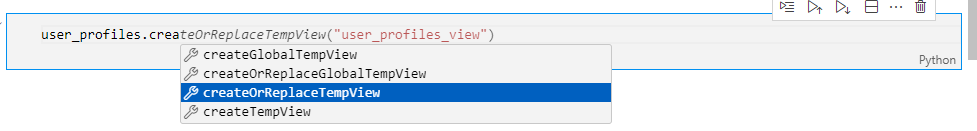
##### Example

```python
#Temp View
df.createOrReplaceTempView("user_view")
spark.sql("SELECT * FROM user_view")

# Global Temp View
df.createGlobalTempView("user_view")
spark.sql("SELECT * FROM global_temp.user_view")


In [13]:
user_profiles.createOrReplaceGlobalTempView("global_user_profiles_view")
spark.sql("SELECT * FROM global_temp.global_user_profiles_view").show()


+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|user_id|           name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|
+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|    101|       John Doe|john.doe@example.com|  Male|   1990-05-15|      USA| 2020-01-10|     true|           1500|
|      2|     Jane Smith|jane.smith@exampl...|Female|   1985-08-20|   Canada| 2019-03-15|     true|           2300|
|      3|   Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|       UK| 2021-07-01|    false|            800|
|      4|    Emily Davis|emily.davis@examp...|Female|   1995-02-25|    India| 2020-05-20|     true|           1200|
|      5|  Michael Brown|michael.brown@exa...|  Male|   1988-09-12|      USA| 2018-11-30|     true|           4500|
|      6|   Sarah Wilson|sarah.wilson@exam...|Female|   1993-06-18|Austr

In [45]:
spark.catalog.dropGlobalTempView("global_user_profiles_view")

False

#### Can use Group by and order as well

Write a query to find the number of users in each country and display the results in descending order of user count.

In [ ]:
spark.sql("""
SELECT country, COUNT(*) AS user_count
FROM user_profiles_view
GROUP BY country
ORDER BY user_count DESC
""").show()

+---------+----------+
|  country|user_count|
+---------+----------+
|      USA|        13|
|    India|         7|
|       UK|         7|
|   Canada|         7|
|Australia|         6|
|  Germany|         5|
|   France|         5|
+---------+----------+



You are working with Apache Spark and have a view user_profiles_view containing user details.

#### Question:

Write a query to fetch user_id and name of users who are inactive.

In [16]:
spark.sql("SELECT user_id, name FROM user_profiles_view WHERE is_active = false").show()


+-------+-----------------+
|user_id|             name|
+-------+-----------------+
|      3|     Mark Johnson|
|      6|     Sarah Wilson|
|      9|      Chris Evans|
|     13|       Liam Brown|
|     17|       Lucas King|
|     21|      James Scott|
|     25|   William Nelson|
|     29|Alexander Roberts|
|     33|   Matthew Parker|
|     37|   Samuel Stewart|
|     43|      Joshua Bell|
|     47|      Jack Cooper|
+-------+-----------------+



#### Can use Aggregations 

Write a query to calculate the average number of followers for users in each country and display the results in descending order.

In [17]:
spark.sql("""
SELECT country, AVG(followers_count) AS avg_followers
FROM user_profiles_view
GROUP BY country
ORDER BY avg_followers DESC
""").show()

+---------+------------------+
|  country|     avg_followers|
+---------+------------------+
|      USA| 3369.230769230769|
|    India| 2064.285714285714|
|   Canada| 2042.857142857143|
|  Germany|            1840.0|
|Australia|            1575.0|
|       UK|1121.4285714285713|
|   France|             880.0|
+---------+------------------+



### Users who singed up in the year 2021

Write a query to retrieve user_id, name, signup_date, and signup_year for users who signed up in the year 2021.

In [18]:
from pyspark.sql.functions import current_date, year
# Add a column for signup year if not already present
user_profiles = user_profiles.withColumn("signup_year", year("signup_date"))
user_profiles.createOrReplaceTempView("user_profiles_view")
spark.sql("""
SELECT user_id, name, signup_date,signup_year
FROM user_profiles_view
WHERE signup_year = 2021
""").show()

+-------+-----------------+-----------+-----------+
|user_id|             name|signup_date|signup_year|
+-------+-----------------+-----------+-----------+
|      3|     Mark Johnson| 2021-07-01|       2021|
|      6|     Sarah Wilson| 2021-01-15|       2021|
|     10|      Emma Watson| 2021-03-01|       2021|
|     14|       Ava Wilson| 2021-05-10|       2021|
|     20|  Charlotte Young| 2021-02-17|       2021|
|     24|     Evelyn Baker| 2021-06-06|       2021|
|     29|Alexander Roberts| 2021-01-20|       2021|
|     32|Victoria Campbell| 2021-04-02|       2021|
|     36|    Sofia Collins| 2021-05-27|       2021|
|     41|      Andrew Cook| 2021-02-11|       2021|
|     44|     Sofia Murphy| 2021-03-25|       2021|
|     47|      Jack Cooper| 2021-06-15|       2021|
|     50|      Lily Howard| 2021-01-08|       2021|
+-------+-----------------+-----------+-----------+



#### Gender Distribution
Write a query to count the number of users for each gender.

In [19]:
spark.sql("""
SELECT gender, COUNT(*) AS count
FROM user_profiles_view
GROUP BY gender
""").show()

+------+-----+
|gender|count|
+------+-----+
|Female|   25|
|  Male|   25|
+------+-----+



### Find users with most followers 

Write a query to retrieve the top 5 users with the highest number of followers.

In [20]:
spark.sql("""
SELECT user_id, name, followers_count
FROM user_profiles_view
ORDER BY followers_count DESC
LIMIT 5
""").show()

+-------+------------------+---------------+
|user_id|              name|followers_count|
+-------+------------------+---------------+
|     11|     Robert Downey|           5000|
|      5|     Michael Brown|           4500|
|     35|    Joseph Edwards|           4100|
|     27|    Henry Mitchell|           3700|
|     45|Christopher Bailey|           3600|
+-------+------------------+---------------+



### Advanced Queries

In [21]:
spark.sql("select * from user_profiles_view").explain(True)

== Parsed Logical Plan ==
'Project [*]
+- 'UnresolvedRelation [user_profiles_view], [], false

== Analyzed Logical Plan ==
user_id: int, name: string, email: string, gender: string, date_of_birth: date, country: string, signup_date: date, is_active: boolean, followers_count: int, signup_year: int
Project [user_id#207, name#208, email#209, gender#210, date_of_birth#211, country#212, signup_date#213, is_active#214, followers_count#215, signup_year#433]
+- SubqueryAlias user_profiles_view
   +- View (`user_profiles_view`, [user_id#207,name#208,email#209,gender#210,date_of_birth#211,country#212,signup_date#213,is_active#214,followers_count#215,signup_year#433])
      +- Project [user_id#207, name#208, email#209, gender#210, date_of_birth#211, country#212, signup_date#213, is_active#214, followers_count#215, year(signup_date#213) AS signup_year#433]
         +- Relation [user_id#207,name#208,email#209,gender#210,date_of_birth#211,country#212,signup_date#213,is_active#214,followers_count#215

### Pro Tips for Writing Catalyst-Friendly Spark SQL

- **Always filter early:**  
  Apply `WHERE` clauses as soon as possible to reduce data size and improve performance.

- **Avoid `SELECT *`:**  
  Only select the columns you need. This reduces data shuffling and speeds up queries.

- **Use explicit joins with keys:**  
  Always specify join keys to avoid cartesian products and ensure efficient joins.
  ```sql
  SELECT a.*, b.*
  FROM tableA a
  JOIN tableB b ON a.cust_id = b.cust_id
  ```

- **Enable broadcast hints for small tables:**  
  Use broadcast joins to optimize joins when one table is small.
  ```python
  from pyspark.sql.functions import broadcast
  df_large.join(broadcast(df_small), "cust_id")
  ```

- **Inspect the execution plan:**  
  Use `.explain(True)` to see the physical and logical plan for your query.
  ```python
  spark.sql("SELECT ...").explain(True)
  ```

<sub><sup>Keep queries concise and efficient for best Spark performance!</sup></sub>

# Catalyst Optimizer Strategies

- **Predicate Pushdown**  
  Pushes filters (e.g., `WHERE`) to the data source to reduce data read.

- **Constant Folding**  
  Evaluates constant expressions (e.g., `1 + 2`) at compile time.

- **Filter Reordering**  
  Reorders/compresses filters for efficiency; removes redundant filters.

- **Projection Pruning**  
  Excludes unused columns to minimize data read and processing.

- **Subquery Elimination**  
  Flattens unnecessary subqueries to simplify the plan.


### Partitioning Strategy

In [23]:
df = spark.read.option("header", True).csv("file:///C:/docs/partitiontable.csv")
df.show()


+-----+---+-------+
| name|age|country|
+-----+---+-------+
|Alice| 25|  India|
|  Bob| 30|    USA|
| Emma| 28|  India|
|  Sam| 35|     UK|
+-----+---+-------+



In [24]:
df.write.mode("overwrite").option("path", "file:///C:/docs/temp").saveAsTable("Non_partitioned_table")

In [25]:
df.write.mode("overwrite").partitionBy("country").option("path", "file:///C:/docs/temp2").saveAsTable("partitioned_table")

In [46]:
spark.sql("SELECT * FROM Non_partitioned_table WHERE country = 'India'").show()


+-----+---+-------+
| name|age|country|
+-----+---+-------+
|Alice| 25|  India|
| Emma| 28|  India|
+-----+---+-------+



In [29]:
spark.sql("SELECT * FROM Non_partitioned_table WHERE country = 'India'").explain(True)


== Parsed Logical Plan ==
'Project [*]
+- 'Filter ('country = India)
   +- 'UnresolvedRelation [Non_partitioned_table], [], false

== Analyzed Logical Plan ==
name: string, age: string, country: string
Project [name#372, age#373, country#374]
+- Filter (country#374 = India)
   +- SubqueryAlias spark_catalog.default.non_partitioned_table
      +- Relation spark_catalog.default.non_partitioned_table[name#372,age#373,country#374] parquet

== Optimized Logical Plan ==
Filter (isnotnull(country#374) AND (country#374 = India))
+- Relation spark_catalog.default.non_partitioned_table[name#372,age#373,country#374] parquet

== Physical Plan ==
*(1) Filter (isnotnull(country#374) AND (country#374 = India))
+- *(1) ColumnarToRow
   +- FileScan parquet spark_catalog.default.non_partitioned_table[name#372,age#373,country#374] Batched: true, DataFilters: [isnotnull(country#374), (country#374 = India)], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/C:/docs/temp], PartitionFilters: [], Pu

In [29]:
spark.sql("SELECT * FROM partitioned_table WHERE country = 'India'").explain(True)


== Parsed Logical Plan ==
'Project [*]
+- 'Filter ('country = India)
   +- 'UnresolvedRelation [partitioned_table], [], false

== Analyzed Logical Plan ==
name: string, age: string, country: string
Project [name#625, age#626, country#627]
+- Filter (country#627 = India)
   +- SubqueryAlias spark_catalog.default.partitioned_table
      +- Relation spark_catalog.default.partitioned_table[name#625,age#626,country#627] parquet

== Optimized Logical Plan ==
Filter (isnotnull(country#627) AND (country#627 = India))
+- Relation spark_catalog.default.partitioned_table[name#625,age#626,country#627] parquet

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet spark_catalog.default.partitioned_table[name#625,age#626,country#627] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/C:/docs/temp2/country=India], PartitionFilters: [isnotnull(country#627), (country#627 = India)], PushedFilters: [], ReadSchema: struct<name:string,age:string>



#### Data Cleaning With Spark SQL 

In [30]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()
user_profiles_uncleaned = spark.read.csv("file:///C:/docs/user_profiles_uncleaned.csv", header=True, inferSchema=True)
user_profiles_uncleaned.createOrReplaceTempView("user_profiles_uncleaned_view")

In [31]:
spark.sql("""
select followers_count from user_profiles_uncleaned_view
          """).show()


+---------------+
|followers_count|
+---------------+
|           1500|
|           2300|
|            800|
|           NULL|
|           4500|
|            600|
|           NULL|
|           1800|
|            900|
|           2500|
|           NULL|
|           2100|
|            700|
|           1600|
|           NULL|
|           3400|
|            950|
|           1700|
|           2100|
|           1950|
+---------------+
only showing top 20 rows



In [32]:
spark.sql("""
SELECT user_id, name 
FROM user_profiles_uncleaned_view 
WHERE followers_count IS null;
""").show()

+-------+-------------+
|user_id|         name|
+-------+-------------+
|      4|  Emily Davis|
|      7|    David Lee|
|     11|Robert Downey|
|     15|   Noah Davis|
+-------+-------------+



In [33]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW user_profiles_view_cleaned AS
SELECT * 
FROM user_profiles_uncleaned_view
WHERE followers_count IS NOT NULL
""")

DataFrame[]

In [47]:
spark.sql("""
SELECT * 
FROM user_profiles_view_cleaned
WHERE followers_count IS NULL;
""").show()

+-------+----+-----+------+-------------+-------+-----------+---------+---------------+
|user_id|name|email|gender|date_of_birth|country|signup_date|is_active|followers_count|
+-------+----+-----+------+-------------+-------+-----------+---------+---------------+
+-------+----+-----+------+-------------+-------+-----------+---------+---------------+



### Deduplicate Rows

Create a temporary view named user_profiles_view_deduplicated that contains all unique rows from user_profiles_view_cleaned.

In other words, this removes duplicates at the row level.

In [37]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW user_profiles_view_deduplicated AS
SELECT Distinct(*)
FROM user_profiles_view_cleaned
""")

DataFrame[]

In [38]:
spark.sql(""" select * from user_profiles_view_deduplicated""").collect()

[Row(user_id=5, name='Michael Brown', email='michael.brown@example.com', gender='Male', date_of_birth=datetime.date(1988, 9, 12), country='USA', signup_date=datetime.date(2018, 11, 30), is_active=True, followers_count=4500),
 Row(user_id=38, name='Emily Morris', email='emily.morris@example.com', gender='Female', date_of_birth=datetime.date(1997, 4, 11), country='Australia', signup_date=datetime.date(2020, 9, 9), is_active=True, followers_count=1650),
 Row(user_id=12, name='Olivia Johnson', email='olivia.johnson@example.com', gender='Female', date_of_birth=datetime.date(1996, 10, 10), country='Canada', signup_date=datetime.date(2020, 6, 20), is_active=True, followers_count=2100),
 Row(user_id=23, name='Benjamin Adams', email='benjamin.adams@example.com', gender='Male', date_of_birth=datetime.date(1990, 4, 21), country='USA', signup_date=datetime.date(2019, 8, 8), is_active=True, followers_count=3100),
 Row(user_id=18, name='Isabella Hall', email='isabella.hall@example.com', gender='Fema

SQL Querying

1. Intoduction (Basic Queries)
2. Aggegations and Grouping
3. Joins and subqueries
4. Window functions
5. Common Table Expressions (CTEs)
6. Handling Complex datatypes
7. Integrating with Different data sources 

## Spark SQL: What It Supports & What To Do When It Doesn’t


| Requirement / Feature                    | Spark SQL Supports? | What To Use Instead / Workaround                     |
|------------------------------------------|----------------------|-------------------------------------------------------|
| **Basic SQL (SELECT, WHERE, GROUP BY)**  | ✔ Yes               | Spark SQL / DataFrame API                            |
| **Joins (inner, left, right, full)**     | ✔ Yes               | Spark SQL / DataFrames                               |
| **Window Functions**                     | ✔ Yes               | Spark SQL / DataFrames                               |
| **Subqueries (correlated & uncorrelated)** | ✔ Yes             | Spark SQL                                             |
| **CTEs (WITH clauses)**                  | ✔ Yes               | Spark SQL                                             |
| **Aggregations (SUM, AVG, COUNT, etc.)** | ✔ Yes               | Spark SQL                                             |
| **DDL (CREATE TABLE, DROP TABLE)**       | ✔ Yes               | Spark SQL                                             |
| **DML (INSERT, INSERT OVERWRITE)**       | ✔ Yes               | Spark SQL                                             |
| **Hive SQL Compatibility**               | ✔ Yes               | Enable Hive Support                                   |
| **Complex SQL (CUBE, ROLLUP, GROUPING SETS)** | ✔ Yes         | Spark SQL                                             |
| **Transactions (BEGIN / COMMIT / ROLLBACK)** | ❌ No            | Delta Lake (ACID), Iceberg, or Hudi                  |
| **MERGE / UPSERT**                       | ⚠ Partial           | Delta Lake for full MERGE support                    |
| **Stored Procedures (PL/SQL, T-SQL)**    | ❌ No               | Write logic in PySpark / Scala code                  |
| **Triggers (BEFORE/AFTER INSERT/UPDATE)**| ❌ No               | Use ETL logic (Airflow, NiFi) or Streaming           |
| **Advanced Indexing (B-tree, GIN, GiST)**| ❌ No               | Partitioning, Bucketing, Z-Ordering (Delta)          |
| **Materialized Views**                   | ❌ No               | Create tables and refresh manually via jobs          |
| **Foreign Keys**                         | ❌ No               | Enforce in ETL or Delta CHECK constraints            |
| **Primary Keys / Unique Keys**           | ⚠ Not enforced     | Delta constraints, ETL validation                    |
| **Triggers on Tables**                   | ❌ No               | Streaming or pipeline workflows                      |
| **Stored Functions**                     | ⚠ Limited UDFs      | PySpark/Scala UDFs, Pandas UDFs                      |
